In [1]:
# =============================================================================
# Longstaff-Schwartz (2001) — Least Squares Monte Carlo (LSM)
# Replicating Section 3: Valuing American Put Options (Table 1)
# =============================================================================
# Paper: "Valuing American Options by Simulation: A Simple Least-Squares
#         Approach", Review of Financial Studies, Vol. 14, No. 1, pp. 113-147
#
# Setup:
#   - American put on a non-dividend-paying stock
#   - Stock follows GBM:  dS = r*S*dt + sigma*S*dZ  (risk-neutral measure)
#   - Exercisable 50 times per year (Bermuda-style)
#   - Basis functions: constant + first 3 weighted Laguerre polynomials
#   - 100,000 paths (50,000 + 50,000 antithetic)
# =============================================================================


In [2]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [3]:
%run models.ipynb

In [4]:
# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)

In [5]:
# =============================================================================
# Path simulation  (antithetic variates)
# =============================================================================
 
def simulate_paths(S0, r, sigma, T, n_steps, n_paths):
    """
    Simulate n_paths GBM stock-price paths with n_steps time steps.
    Uses antithetic variates: first half uses Z, second half uses -Z.
    Returns array of shape (n_paths, n_steps + 1).
    """
    dt = T / n_steps
    half = n_paths // 2
 
    Z = np.random.standard_normal((half, n_steps))   # shape: (half, n_steps)
    Z_full = np.concatenate([Z, -Z], axis=0)          # antithetic
 
    # Log-normal increments
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_full
    log_paths = np.zeros((n_paths, n_steps + 1))
    log_paths[:, 0] = np.log(S0)
    log_paths[:, 1:] = np.log(S0) + np.cumsum(increments, axis=1)
 
    return np.exp(log_paths)

In [6]:
# =============================================================================
# Replicate Table 1 from the paper (Pricing An American Put Options)
# =============================================================================
 
# Fixed parameters (Table 1 caption)
K   = 40.0      # strike price
r   = 0.06      # risk-free rate
 
# Grid of (S0, sigma, T) matching the 20 rows in Table 1
param_grid = [
    # (S0, sigma, T)
    (36, 0.20, 1), (36, 0.20, 2),
    (36, 0.40, 1), (36, 0.40, 2),
    (38, 0.20, 1), (38, 0.20, 2),
    (38, 0.40, 1), (38, 0.40, 2),
    (40, 0.20, 1), (40, 0.20, 2),
    (40, 0.40, 1), (40, 0.40, 2),
    (42, 0.20, 1), (42, 0.20, 2),
    (42, 0.40, 1), (42, 0.40, 2),
    (44, 0.20, 1), (44, 0.20, 2),
    (44, 0.40, 1), (44, 0.40, 2),
]
 
print("=" * 130)
print(
    f"{'S':>6} {'σ':>8} {'T':>6} | "
    f"{'FD American':>15} {'FD Ex Value':>14} | "
    f"{'LSM American':>15} {'(s.e.)':>10} "
    f"{'BS European':>15} {'LSM Ex Value':>14} {'Δ Ex Value':>14}"
)

print("-" * 130)
results = []
for i, (S0, sigma, T) in enumerate(param_grid):
 
    # LSM price
    am_price, eu_price, se = lsm_american_put(
        S0, K, r, sigma, T, simulate_paths,
        n_steps_per_year=50,
        n_paths=100_000
    )
 
    # Closed-form European
    bs_eu = bs_european_put(S0, K, r, sigma, T)
    fd_am = fd_american_put(S0, K, r, sigma, T)
    # Early exercise values
    fd_ee  = fd_am - bs_eu
    lsm_ee = am_price - bs_eu
    diff   = fd_ee - lsm_ee
 
    results.append({
        'S': S0, 'sigma': sigma, 'T': T,
        'FD_American': fd_am,   'FD_Early_Exercise_Value': fd_ee,
        'LSM_American': am_price, 'SE': se,
        'BS_European': bs_eu,   'LSM_Early_Exercise_Value': lsm_ee,
        'Diff_EE': diff
    })
 
    print(f"{S0:>6} {sigma:>8.2f} {T:>6} | "
          f"{fd_am:>15.3f} {fd_ee:>14.3f} | "
          f"{am_price:>15.3f} ({se:.3f}) {bs_eu:>15.3f} {lsm_ee:>14.3f} {diff:>14.3f}")
 
print("=" * 130)
 

     S        σ      T |     FD American    FD Ex Value |    LSM American     (s.e.)     BS European   LSM Ex Value     Δ Ex Value
----------------------------------------------------------------------------------------------------------------------------------
    36     0.20      1 |           4.486          0.642 |           4.479 (0.009)           3.844          0.635          0.008
    36     0.20      2 |           4.848          1.085 |           4.846 (0.011)           3.763          1.083          0.003
    36     0.40      1 |           7.109          0.397 |           7.106 (0.019)           6.711          0.395          0.002
    36     0.40      2 |           8.514          0.814 |           8.499 (0.023)           7.700          0.799          0.015
    38     0.20      1 |           3.257          0.405 |           3.256 (0.009)           2.852          0.404          0.001
    38     0.20      2 |           3.751          0.761 |           3.738 (0.011)           2.991 

In [9]:
# =============================================================================
# 6.  Summary statistics on the 20 differences
# =============================================================================
 
diffs = np.array([r['Diff_EE'] for r in results])
abs_diffs = np.abs(diffs)
 
print("\n── Summary of |EE Diff| (FD − LSM) ──")
print(f"  Mean absolute difference : {abs_diffs.mean():.4f}")
print(f"  Max  absolute difference : {abs_diffs.max():.4f}")
print(f"  Rows with |diff| ≤ $0.01 : {(abs_diffs <= 0.01).sum()} / {len(diffs)}")
print(f"  Positive diffs (FD>LSM)  : {(diffs > 0).sum()}")
print(f"  Negative diffs (LSM>FD)  : {(diffs < 0).sum()}")


── Summary of |EE Diff| (FD − LSM) ──
  Mean absolute difference : 0.0085
  Max  absolute difference : 0.0191
  Rows with |diff| ≤ $0.01 : 13 / 20
  Positive diffs (FD>LSM)  : 19
  Negative diffs (LSM>FD)  : 1


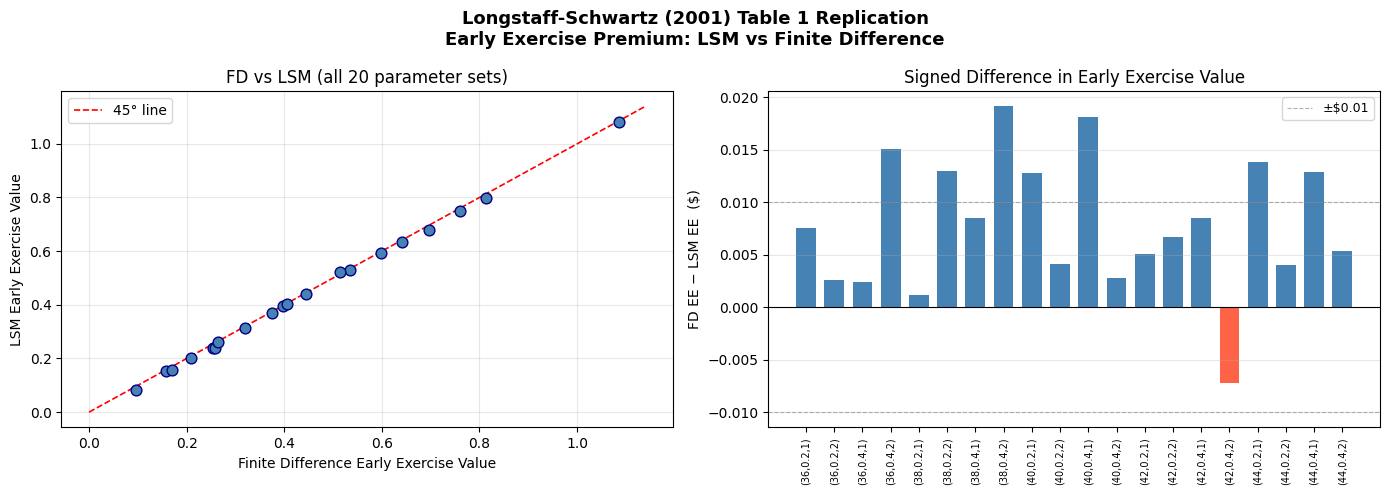

In [11]:
# =============================================================================
#  Visual comparison: LSM vs FD early-exercise premium
# =============================================================================


fd_ee_vals  = [r['FD_Early_Exercise_Value']  for r in results]
lsm_ee_vals = [r['LSM_Early_Exercise_Value'] for r in results]
labels      = [f"S={r['S']}\nσ={r['sigma']}\nT={r['T']}" for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Longstaff-Schwartz (2001) Table 1 Replication\n"
                "Early Exercise Premium: LSM vs Finite Difference",
                fontsize=13, fontweight='bold')

# ── Scatter: FD vs LSM early-exercise value ───────────────────────────────
ax = axes[0]
ax.scatter(fd_ee_vals, lsm_ee_vals, color='steelblue', edgecolors='navy',
            s=60, zorder=3)
lims = [0, max(max(fd_ee_vals), max(lsm_ee_vals)) * 1.05]
ax.plot(lims, lims, 'r--', lw=1.2, label='45° line')
ax.set_xlabel("Finite Difference Early Exercise Value")
ax.set_ylabel("LSM Early Exercise Value")
ax.set_title("FD vs LSM (all 20 parameter sets)")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Bar chart: signed differences ────────────────────────────────────────
ax2 = axes[1]
colors = ['tomato' if d < 0 else 'steelblue' for d in diffs]
x = np.arange(len(diffs))
ax2.bar(x, diffs, color=colors, edgecolor='none', width=0.7)
ax2.axhline(0, color='black', lw=0.8)
ax2.axhline( 0.01, color='grey', lw=0.8, ls='--', alpha=0.6)
ax2.axhline(-0.01, color='grey', lw=0.8, ls='--', alpha=0.6, label='±$0.01')
ax2.set_xticks(x)
ax2.set_xticklabels([f"({r['S']},{r['sigma']},{r['T']})" for r in results],
                    rotation=90, fontsize=7)
ax2.set_ylabel("FD EE − LSM EE  ($)")
ax2.set_title("Signed Difference in Early Exercise Value")
ax2.legend(fontsize=9)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## <u>Comparison Between Finite Difference and LSM</u>
As shown, the differences between the finite difference and LSM algorithms are typically very small. Of the 20 differences shown in Table 1, 13 are less than or equal to 1 cent in absolute value. The standard errors for the simulated values range from 0.6 to 2.3 cents, which is well within the market bid-ask spread for these types of options.

In addition, the differences are both positive and negative. These results suggest that the LSM algorithm is able to approximate closely the finite-difference values.